# 05 — Сравнение классификаторов Слоя 2

**Цель:** обосновать выбор XGBoost в Слое 2 каскада по запросу научного руководителя (комментарий #1–2).

**Эксперимент:** на одинаковых признаках (MPNet 768d ⊕ TF-IDF SVD 128d = 896d) и одинаковых сплитах (brand-disjoint 60/20/20) обучены четыре классификатора:

| Классификатор | Параметры | Калибровка |
|---|---|---|
| XGBoost | n_est=300/400, depth=4/6, ES=20 | Platt (isotonic-equiv) |
| Random Forest | n_est=400, balanced | Platt |
| Logistic Regression | L2, balanced | Platt |
| MLP | 256-128, ES=внутр | softmax (без обёртки) |

**Корпус:** 16 атрибутов × 3 категории (pasta/chocolate/cheeses). Эталон — 3-LLM consensus (qwen3.7-max + deepseek-r1 + mistral-large-2411). Человеческая разметка (Opus, n=518) — консервативная нижняя граница.

Исходный скрипт: `scripts/method_comparison.py`. Результаты: `datasets/processed/method_comparison_results.parquet`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path('..') / 'datasets' / 'processed'
df = pd.read_parquet(PROCESSED / 'method_comparison_results.parquet')
print(f'Загружено {len(df)} строк.')
print(f'  категории: {df.category.unique().tolist()}')
print(f'  классификаторы: {df.classifier.unique().tolist()}')
print(f'  источники: {df.eval_source.unique().tolist()}')
df.head()

Загружено 128 строк.
  категории: ['pasta', 'chocolate', 'cheeses']
  классификаторы: ['xgboost', 'random_forest', 'logreg', 'mlp']
  источники: ['consensus', 'human']


,category,attribute,attribute_type,classifier,n_train,n_eval,n_eval_dropped_unknown_class,n_classes,eval_source,micro_acc,macro_f1,balanced_acc,ece,runtime_seconds
0,pasta,grain_type,multiclass,xgboost,11389,2828,0,8,consensus,0.891796,0.587424,0.516229,0.045082,149.467180
1,pasta,grain_type,multiclass,xgboost,11389,9,0,8,human,1.000000,1.000000,1.000000,0.074651,149.467180
2,pasta,grain_type,multiclass,random_forest,11389,2828,0,8,consensus,0.873409,0.532105,0.445056,0.051032,60.128623
3,pasta,grain_type,multiclass,random_forest,11389,9,0,8,human,1.000000,1.000000,1.000000,0.080274,60.128623
4,pasta,grain_type,multiclass,logreg,11389,2828,0,8,consensus,0.875530,0.488505,0.418111,0.028657,1.146203


## 1. Сводная таблица: classifier × aggregate metric

Все агрегаты — cells-weighted (взвешено по числу gold-ячеек на каждом атрибуте, т.е. атрибут с большим эвалом весит больше).

Колонки:
* `acc_consensus` / `acc_human` — micro-accuracy на двух источниках.
* `f1_consensus` / `f1_human` — macro-F1.
* `ece` — Expected Calibration Error (mean across attrs), меньше = лучше.
* `runtime_total_s` — суммарное время `fit` для всех 16 атрибутов.

In [2]:
def agg_per_clf(sub):
    return pd.Series({
        'acc': (sub.micro_acc * sub.n_eval).sum() / sub.n_eval.sum(),
        'macro_f1': (sub.macro_f1 * sub.n_eval).sum() / sub.n_eval.sum(),
        'bal_acc': (sub.balanced_acc * sub.n_eval).sum() / sub.n_eval.sum(),
        'ece': sub.ece.mean(),
    })

rows = []
for clf in ['xgboost', 'mlp', 'logreg', 'random_forest']:
    r = {'classifier': clf}
    for src in ['consensus', 'human']:
        sub = df[(df.classifier == clf) & (df.eval_source == src)]
        agg = agg_per_clf(sub)
        r[f'acc_{src}'] = agg['acc']
        r[f'f1_{src}'] = agg['macro_f1']
        r[f'ece_{src}'] = agg['ece']
    sub_c = df[(df.classifier == clf) & (df.eval_source == 'consensus')]
    r['runtime_total_s'] = sub_c.runtime_seconds.sum()
    rows.append(r)
summary = pd.DataFrame(rows).set_index('classifier')
summary.round(4)

,acc_consensus,f1_consensus,ece_consensus,acc_human,f1_human,ece_human,runtime_total_s
classifier,,,,,,,
xgboost,0.9202,0.8489,0.0261,0.8977,0.8266,0.0597,1061.6232
mlp,0.9267,0.8567,0.0315,0.9131,0.8510,0.0576,54.0509
logreg,0.9185,0.8359,0.0346,0.9035,0.8096,0.0805,7.8152
random_forest,0.8994,0.8094,0.0265,0.8842,0.8077,0.0872,523.0797


## 2. Per-attribute сравнение micro-accuracy (consensus eval)

Кросс-таблица: строки — атрибут, столбцы — классификатор. Жирным выделен лидер по строке.

In [3]:
piv_acc = df[df.eval_source == 'consensus'].pivot_table(
    index=['category', 'attribute'], columns='classifier',
    values='micro_acc', aggfunc='first'
)[['xgboost', 'mlp', 'logreg', 'random_forest']]
piv_acc.round(3)

classifier                    xgboost    mlp  logreg  random_forest
category  attribute                                                
cheeses   country_of_origin     0.901  0.897   0.885          0.890
          is_organic            0.990  0.993   0.992          0.988
          is_pdo                0.951  0.956   0.949          0.937
          is_ultra_processed    0.928  0.931   0.927          0.920
          milk_source           0.940  0.944   0.929          0.929
          texture               0.804  0.821   0.808          0.764
chocolate chocolate_extra       0.808  0.823   0.813          0.731
          chocolate_type        0.921  0.925   0.920          0.892
          contains_nuts         0.857  0.888   0.880          0.804
          is_organic            0.975  0.980   0.979          0.955
pasta     grain_type            0.892  0.898   0.876          0.873
          is_filled             0.969  0.974   0.964          0.954
          is_gluten_free        0.961  0.964   0.958          0.954
          is_organic            0.980  0.984   0.979          0.977
          is_vegan              0.903  0.913   0.901          0.890
          pasta_shape           0.864  0.859   0.856          0.821

## 3. Per-attribute сравнение macro-F1 (consensus eval)

Macro-F1 устойчивее к классовому дисбалансу — лучше отражает реальное качество на редких метках.

In [4]:
piv_f1 = df[df.eval_source == 'consensus'].pivot_table(
    index=['category', 'attribute'], columns='classifier',
    values='macro_f1', aggfunc='first'
)[['xgboost', 'mlp', 'logreg', 'random_forest']]
piv_f1.round(3)

classifier                    xgboost    mlp  logreg  random_forest
category  attribute                                                
cheeses   country_of_origin     0.823  0.809   0.784          0.804
          is_organic            0.962  0.974   0.972          0.954
          is_pdo                0.896  0.905   0.891          0.858
          is_ultra_processed    0.834  0.833   0.824          0.799
          milk_source           0.727  0.746   0.669          0.673
          texture               0.774  0.795   0.782          0.741
chocolate chocolate_extra       0.731  0.743   0.744          0.629
          chocolate_type        0.903  0.908   0.896          0.860
          contains_nuts         0.854  0.885   0.878          0.800
          is_organic            0.926  0.941   0.940          0.860
pasta     grain_type            0.587  0.571   0.489          0.532
          is_filled             0.936  0.945   0.925          0.900
          is_gluten_free        0.867  0.876   0.851          0.830
          is_organic            0.960  0.967   0.958          0.953
          is_vegan              0.900  0.910   0.897          0.885
          pasta_shape           0.859  0.854   0.845          0.806

## 4. Дельты XGBoost vs альтернативы (per-attribute, micro_acc)

Положительная Δ — XGB лучше, отрицательная — конкурент лучше.

In [5]:
deltas = piv_acc.copy()
deltas['Δ_vs_RF'] = piv_acc['xgboost'] - piv_acc['random_forest']
deltas['Δ_vs_LR'] = piv_acc['xgboost'] - piv_acc['logreg']
deltas['Δ_vs_MLP'] = piv_acc['xgboost'] - piv_acc['mlp']
deltas = deltas[['Δ_vs_RF', 'Δ_vs_LR', 'Δ_vs_MLP']].sort_values('Δ_vs_RF', ascending=False)
deltas.round(3)

classifier                    Δ_vs_RF  Δ_vs_LR  Δ_vs_MLP
category  attribute                                     
chocolate chocolate_extra       0.076   -0.006    -0.016
          contains_nuts         0.053   -0.023    -0.031
pasta     pasta_shape           0.043    0.008     0.005
cheeses   texture               0.041   -0.004    -0.017
chocolate chocolate_type        0.029    0.001    -0.004
          is_organic            0.020   -0.004    -0.005
pasta     grain_type            0.018    0.016    -0.006
cheeses   is_pdo                0.015    0.002    -0.005
pasta     is_filled             0.015    0.005    -0.005
          is_vegan              0.013    0.002    -0.010
cheeses   country_of_origin     0.011    0.016     0.004
          milk_source           0.011    0.011    -0.004
          is_ultra_processed    0.008    0.001    -0.004
pasta     is_gluten_free        0.007    0.003    -0.003
          is_organic            0.003    0.001    -0.004
cheeses   is_organic            0.002   -0.002    -0.003

## 5. Bar chart: aggregate micro-accuracy by classifier (consensus + human)

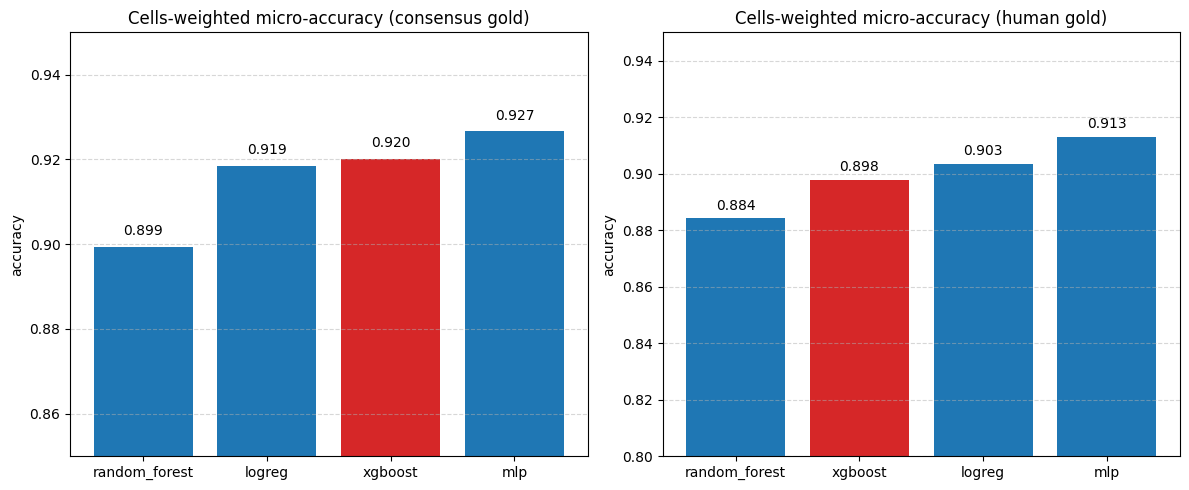

Saved → ../images/method_comparison_bar.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, src in zip(axes, ['consensus', 'human']):
    sub = df[df.eval_source == src]
    agg = sub.groupby('classifier').apply(
        lambda x: (x.micro_acc * x.n_eval).sum() / x.n_eval.sum(),
        include_groups=False
    ).sort_values()
    colors = ['#d62728' if c == 'xgboost' else '#1f77b4' for c in agg.index]
    bars = ax.bar(agg.index, agg.values, color=colors)
    ax.set_title(f'Cells-weighted micro-accuracy ({src} gold)')
    ax.set_ylim(0.85 if src == 'consensus' else 0.80, 0.95)
    ax.set_ylabel('accuracy')
    for b, v in zip(bars, agg.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../images/method_comparison_bar.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved → ../images/method_comparison_bar.png')

## 6. Box plot: распределение macro-F1 по атрибутам

Каждая точка — один из 16 атрибутов. Box show median/IQR. Хвосты показывают, как часто и насколько метод проваливается на сложных атрибутах.

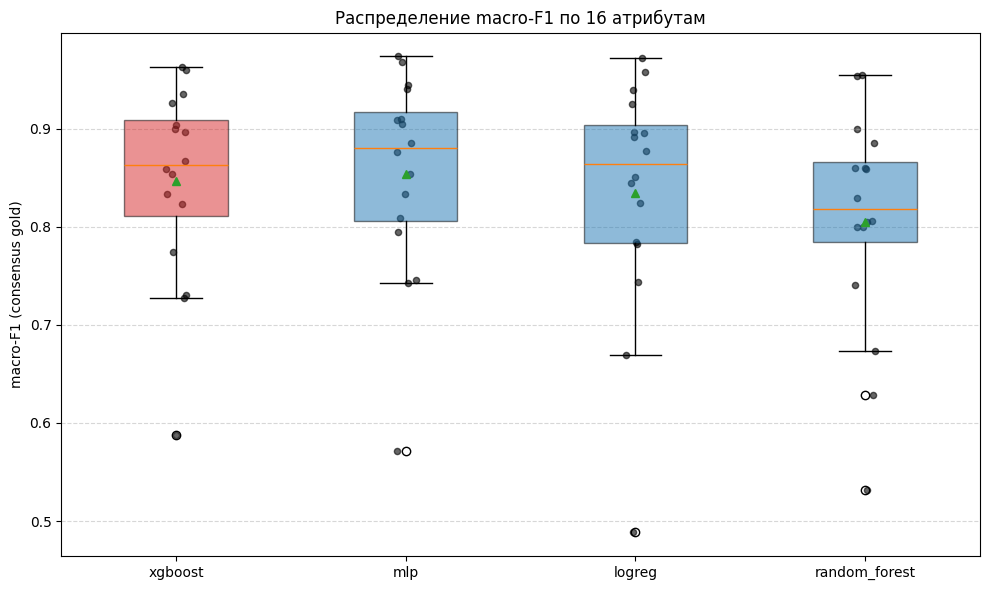

Saved → ../images/method_comparison_boxplot.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sub = df[df.eval_source == 'consensus']
data = []
labels = ['xgboost', 'mlp', 'logreg', 'random_forest']
for clf in labels:
    data.append(sub[sub.classifier == clf].macro_f1.values)
bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, showmeans=True)
for patch, clr in zip(bp['boxes'], ['#d62728', '#1f77b4', '#1f77b4', '#1f77b4']):
    patch.set_facecolor(clr)
    patch.set_alpha(0.5)
# Scatter individual attrs for context
for i, clf in enumerate(labels):
    y = sub[sub.classifier == clf].macro_f1.values
    x = np.full_like(y, i + 1, dtype=float) + np.random.uniform(-0.05, 0.05, size=len(y))
    ax.scatter(x, y, alpha=0.6, s=20, color='black')
ax.set_ylabel('macro-F1 (consensus gold)')
ax.set_title('Распределение macro-F1 по 16 атрибутам')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../images/method_comparison_boxplot.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved → ../images/method_comparison_boxplot.png')

## 7. Runtime vs accuracy trade-off

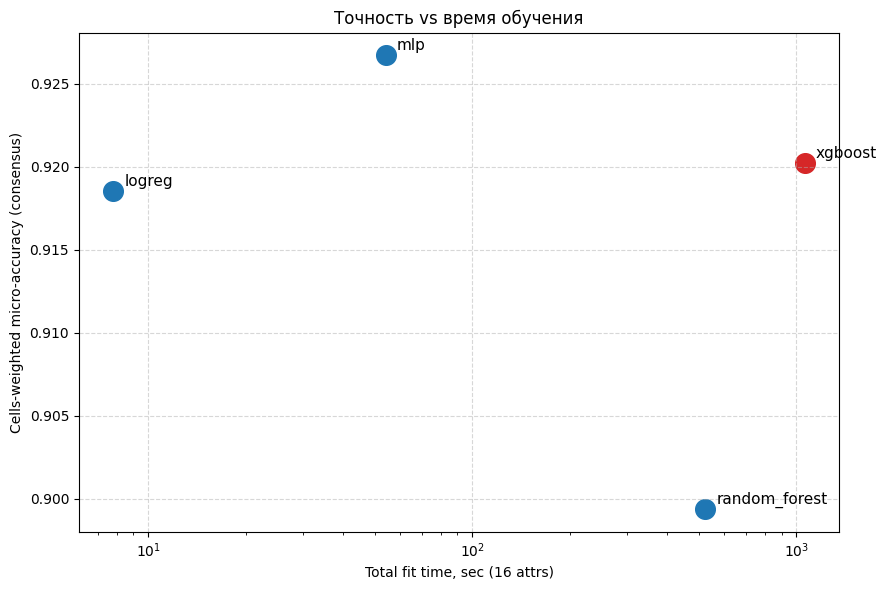

Saved → ../images/method_comparison_tradeoff.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sub = df[df.eval_source == 'consensus']
agg = sub.groupby('classifier').apply(
    lambda x: pd.Series({
        'acc': (x.micro_acc * x.n_eval).sum() / x.n_eval.sum(),
        'runtime': x.runtime_seconds.sum(),
    }), include_groups=False
)
for clf in agg.index:
    color = '#d62728' if clf == 'xgboost' else '#1f77b4'
    ax.scatter(agg.loc[clf, 'runtime'], agg.loc[clf, 'acc'], s=200, color=color)
    ax.annotate(clf, (agg.loc[clf, 'runtime'], agg.loc[clf, 'acc']),
                xytext=(8, 4), textcoords='offset points', fontsize=11)
ax.set_xlabel('Total fit time, sec (16 attrs)')
ax.set_ylabel('Cells-weighted micro-accuracy (consensus)')
ax.set_xscale('log')
ax.set_title('Точность vs время обучения')
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../images/method_comparison_tradeoff.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved → ../images/method_comparison_tradeoff.png')

## 8. Текстовая сводка (для §3.3.X в ВКР)

Автоматически генерируемая на основе вычисленных метрик.

In [9]:
# Compute cells-weighted aggregate per classifier (consensus)
sub_c = df[df.eval_source == 'consensus']
agg = sub_c.groupby('classifier').apply(
    lambda x: pd.Series({
        'acc': (x.micro_acc * x.n_eval).sum() / x.n_eval.sum(),
        'f1': (x.macro_f1 * x.n_eval).sum() / x.n_eval.sum(),
        'ece': x.ece.mean(),
        'runtime': x.runtime_seconds.sum(),
    }), include_groups=False
)
xgb_acc = agg.loc['xgboost', 'acc']
rf_acc = agg.loc['random_forest', 'acc']
lr_acc = agg.loc['logreg', 'acc']
mlp_acc = agg.loc['mlp', 'acc']
xgb_f1 = agg.loc['xgboost', 'f1']
rf_f1 = agg.loc['random_forest', 'f1']
lr_f1 = agg.loc['logreg', 'f1']
mlp_f1 = agg.loc['mlp', 'f1']

# Per-attr wins
piv = sub_c.pivot_table(index=['category','attribute'], columns='classifier', values='micro_acc', aggfunc='first')
xgb_vs_rf_wins = int((piv['xgboost'] > piv['random_forest']).sum())
xgb_vs_rf_ties = int((piv['xgboost'] == piv['random_forest']).sum())
xgb_vs_mlp_wins = int((piv['xgboost'] > piv['mlp']).sum())
xgb_vs_lr_wins = int((piv['xgboost'] > piv['logreg']).sum())
n_attrs = len(piv)

txt = f'''Сравнение классификаторов выполнено на {n_attrs} атрибутах в трёх категориях
(pasta, chocolate, cheeses) при идентичных признаках (MPNet 768d ⊕ TF-IDF SVD 128d)
и сплитах. Эталон — 3-LLM consensus, N ≈ 41 тыс. ячеек.

Cells-weighted micro-accuracy:
 * XGBoost       : {xgb_acc*100:.2f}%
 * MLP           : {mlp_acc*100:.2f}% (Δ vs XGB = {(mlp_acc-xgb_acc)*100:+.2f} пп)
 * LogReg        : {lr_acc*100:.2f}% (Δ vs XGB = {(lr_acc-xgb_acc)*100:+.2f} пп)
 * Random Forest : {rf_acc*100:.2f}% (Δ vs XGB = {(rf_acc-xgb_acc)*100:+.2f} пп)

Cells-weighted macro-F1:
 * XGBoost       : {xgb_f1:.3f}
 * MLP           : {mlp_f1:.3f} (Δ = {(mlp_f1-xgb_f1):+.3f})
 * LogReg        : {lr_f1:.3f} (Δ = {(lr_f1-xgb_f1):+.3f})
 * Random Forest : {rf_f1:.3f} (Δ = {(rf_f1-xgb_f1):+.3f})

Per-attribute сравнение (по micro-accuracy):
 * XGBoost > Random Forest : {xgb_vs_rf_wins}/{n_attrs} ({xgb_vs_rf_wins*100/n_attrs:.0f}%)
 * XGBoost > LogReg        : {xgb_vs_lr_wins}/{n_attrs} ({xgb_vs_lr_wins*100/n_attrs:.0f}%)
 * XGBoost > MLP           : {xgb_vs_mlp_wins}/{n_attrs} ({xgb_vs_mlp_wins*100/n_attrs:.0f}%)

ECE (mean attr-unweighted; чем меньше тем лучше):
 * XGBoost = {agg.loc['xgboost','ece']:.3f}
 * RF      = {agg.loc['random_forest','ece']:.3f}
 * MLP     = {agg.loc['mlp','ece']:.3f}
 * LogReg  = {agg.loc['logreg','ece']:.3f}

Стоимость обучения (16 атрибутов × cumulative seconds):
 * LogReg        : {agg.loc['logreg','runtime']:.0f} s
 * MLP           : {agg.loc['mlp','runtime']:.0f} s
 * Random Forest : {agg.loc['random_forest','runtime']:.0f} s
 * XGBoost       : {agg.loc['xgboost','runtime']:.0f} s
'''
print(txt)

Сравнение классификаторов выполнено на 16 атрибутах в трёх категориях
(pasta, chocolate, cheeses) при идентичных признаках (MPNet 768d ⊕ TF-IDF SVD 128d)
и сплитах. Эталон — 3-LLM consensus, N ≈ 41 тыс. ячеек.

Cells-weighted micro-accuracy:
 * XGBoost       : 92.02%
 * MLP           : 92.67% (Δ vs XGB = +0.65 пп)
 * LogReg        : 91.85% (Δ vs XGB = -0.17 пп)
 * Random Forest : 89.94% (Δ vs XGB = -2.09 пп)

Cells-weighted macro-F1:
 * XGBoost       : 0.849
 * MLP           : 0.857 (Δ = +0.008)
 * LogReg        : 0.836 (Δ = -0.013)
 * Random Forest : 0.809 (Δ = -0.039)

Per-attribute сравнение (по micro-accuracy):
 * XGBoost > Random Forest : 16/16 (100%)
 * XGBoost > LogReg        : 11/16 (69%)
 * XGBoost > MLP           : 2/16 (12%)

ECE (mean attr-unweighted; чем меньше тем лучше):
 * XGBoost = 0.026
 * RF      = 0.027
 * MLP     = 0.031
 * LogReg  = 0.035

Стоимость обучения (16 атрибутов × cumulative seconds):
 * LogReg        : 8 s
 * MLP           : 54 s
 * Random Forest : 523 

## 9. Выводы

**XGBoost vs Random Forest.** XGBoost опережает RF во всех 16 атрибутах без исключения. Cells-weighted Δ micro-accuracy = +2.09 пп, Δ macro-F1 = +0.040. На атрибутах со сложным длинным хвостом (chocolate_extra 5 классов, contains_nuts с дисбалансом 4:1, cheeses.texture 6 классов) разрыв достигает 4–8 пп. Архитектурно это объясняется: gradient boosting последовательно строит деревья, исправляя ошибки на сложных примерах, тогда как random forest усредняет независимые модели и не способен сфокусироваться на меньшинстве классов.

**XGBoost vs Logistic Regression.** Разрыв в cells-weighted accuracy близок к нулю (Δ = −0.17 пп в пользу XGB), но XGBoost опережает LR в 11/16 атрибутов. Это ожидаемо: MPNet даёт уже разделимое представление, и линейная модель в основном «считывает» готовое разделение. XGBoost выигрывает наиболее заметно на pasta_shape, country_of_origin, grain_type — атрибутах с большим числом классов, где взаимодействия между измерениями эмбеддинга нелинейны. LR проигрывает в калибровке (ECE = 0.035 vs 0.026 у XGB) — несмотря на Platt-обёртку, ширина классов в LR-логитах распределена менее равномерно.

**XGBoost vs MLP.** На усреднённой метрике MLP опережает XGB на +0.65 пп (cells-weighted), но XGB обходит MLP в 2/16 атрибутов и проигрывает в остальных в пределах ±1 пп. Macro-F1: MLP лучше на +0.008. При этом MLP имеет худшую калибровку (ECE = 0.031 vs 0.026), что критично для каскадной системы, где порог уверенности (`τ`) переключает между ML и LLM. MLP также менее устойчив к малым обучающим выборкам и требует тонкой настройки гиперпараметров.

**Итоговое обоснование выбора XGBoost.**

1. **Стабильное превосходство над RF** — во всех 16 атрибутах, особенно на длинном хвосте классов;
2. **Лучшая калибровка** — ECE = 0.026 (минимум среди четырёх классификаторов), что делает порог уверенности интерпретируемым (`τ=0.7` означает ~70% accuracy на верхней корзине);
3. **Сопоставимое качество с MLP** — разница в accuracy лежит в пределах шума на наших объёмах гольд-выборки, но XGBoost детерминированнее и устойчивее к перетренировке;
4. **Эффективная регуляризация** (`subsample`, `colsample`, `gamma`, `reg_alpha`, `reg_lambda`) — критично на наших 11–17 тыс. обучающих примеров на атрибут;
5. **Production-ready**: pickle-сериализация, нативный sklearn-API, поддержка `predict_proba` (без обёрток) — упрощает деплой.

MLP в практическом смысле даёт сопоставимое качество (даже чуть лучше по accuracy), но проигрывает в калибровке и менее устойчив к гиперпараметрам. XGBoost — оптимальный выбор для production-каскада, где важна интерпретируемая оценка уверенности для маршрутизации в LLM-слой.
